### Term Project
#### Yiscah Mark

### Analyzing the corrolation between the price of cars and other details.

##### uploading the dataset



In [68]:
from google.colab import files

uploaded = files.upload()

Saving CAR DETAILS FROM CAR DEKHO.csv to CAR DETAILS FROM CAR DEKHO (1).csv


#### Printing the first five lines to explore the dataset.


In [69]:
import pandas as pd
import io

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[filename]))
display(df.head())

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [70]:
print('Dataset shape:', df.shape)
display(df.info())

Dataset shape: (4340, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


None

### The results of the output of this cell is that we have a dataset with 8 columns (consisting of the car details and history) and 4340 rows of data.

#### None of the columns have any missing information, they all came out non-null.
#### The name column, fuel, seller type, transmission, and owner columns all have objects (a word) in them.
#### The rest of the columns: Year, selling price, and kilometers driven columns all have a "int64" which means a number. ( a dollar amount, year, or amount of miles.)


In [71]:
display(df.describe())

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


#### The cell above includes a summary of various statistics for this car data set.The summary is only for those columns that have numbers in the cells.
#### Count: there are 4340 rows of data
#### Mean: The average year, price, and km_driven.
#### std: How spread out is the data? The data is spread over a few years, the prices are over a larger range, and the kilometers driven has an even higher range of values.
#### Min: shows the earliest year, lowest price, and least kilometers driven.
#### 25%, 50%, 75%: shows the quartiles that the data lies in.
#### Max: shows the maximum values of the data.

#### 1.0000 in the kilometers driven seems to be an outlier, it is far less than the mean, average, or any of the quartiles.

##### just confirming that there are no missing values.

In [72]:
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


#### the columns of data are seperated into those that have objects and those that have numbers.

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Numerical columns: {list(numerical_cols)}")
print(f"Categorical columns: {list(categorical_cols)}")

Numerical columns: ['year', 'selling_price', 'km_driven']
Categorical columns: ['name', 'fuel', 'seller_type', 'transmission', 'owner']


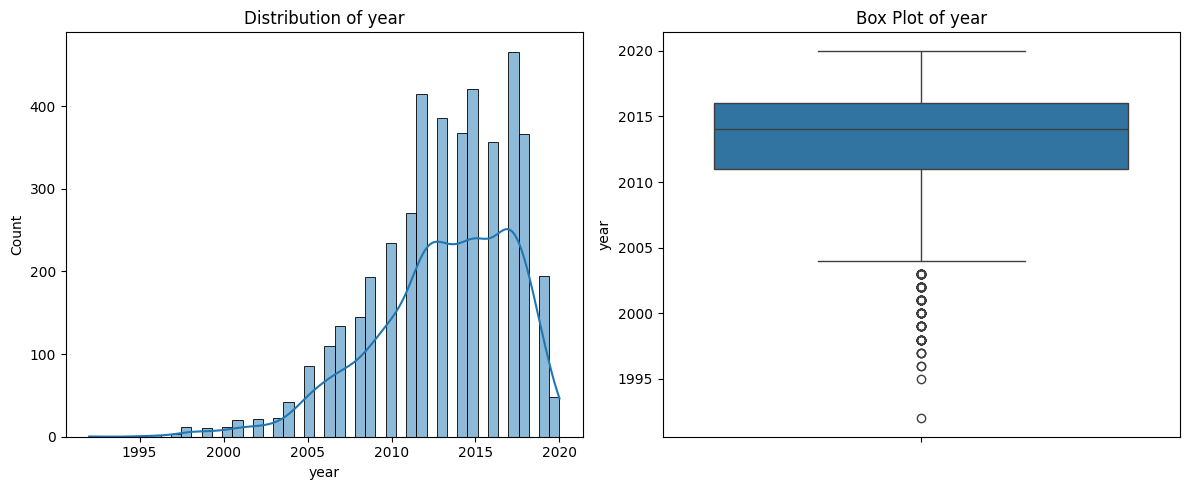

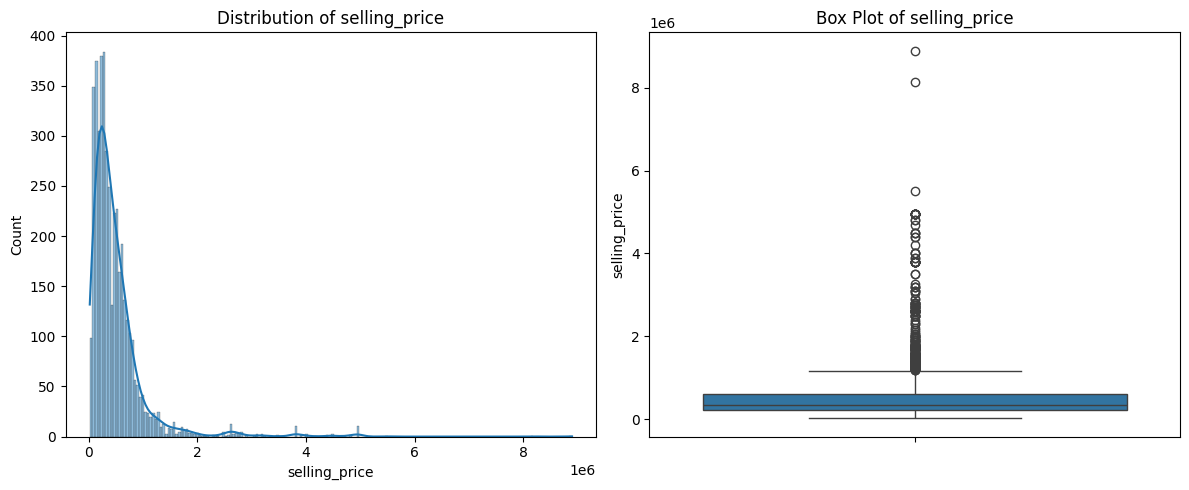

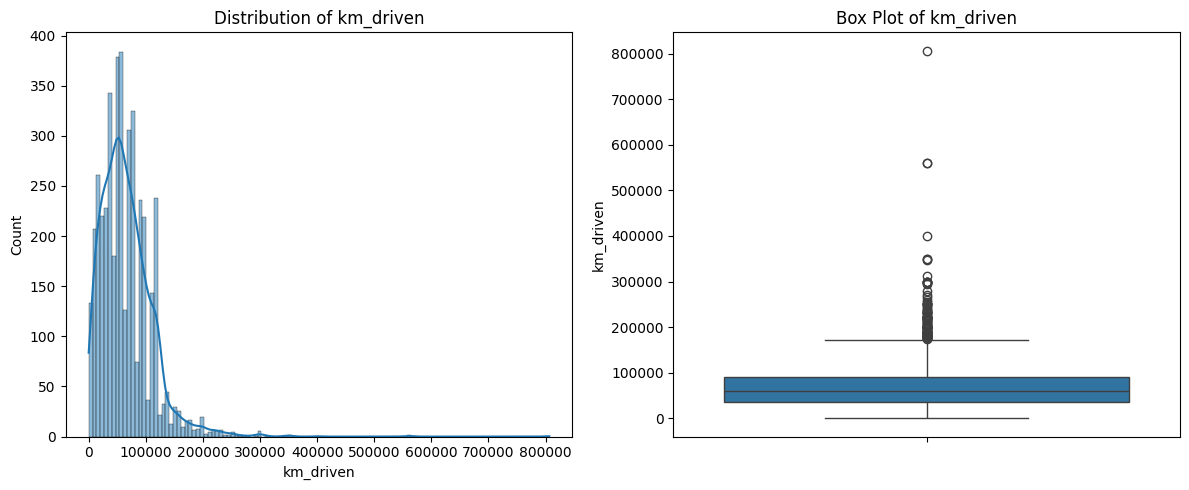

In [74]:
for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Box Plot of {col}')

    plt.tight_layout()
    plt.show()

#### Here we can visulize the distribution of the data in the numerical columns.
#### Year: The figure is skewed to the left. We have a few cars from 1995 till 2004, and then the rest is a pretty normal bell shape that goes dowm close to 2020 as well. In the box and whisker plot they appear more likely to be outliers.
#### Price and kilometers driven: both these columns are skewed to the right. In the price it makes sense that there are a few very expensive cars and the rest are closer to normal. There are many outliers as evident in the box-and-whisker plot.


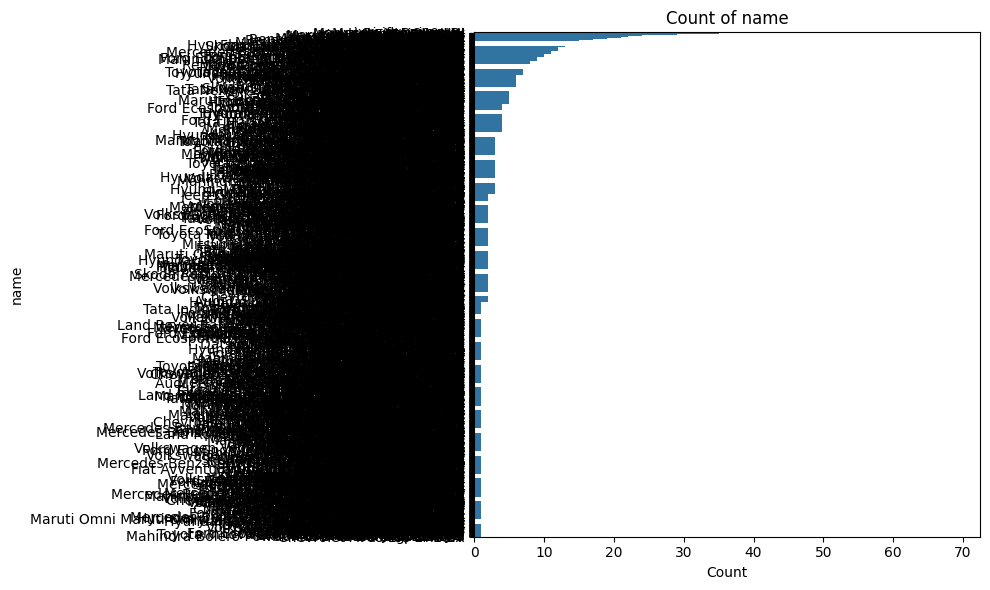

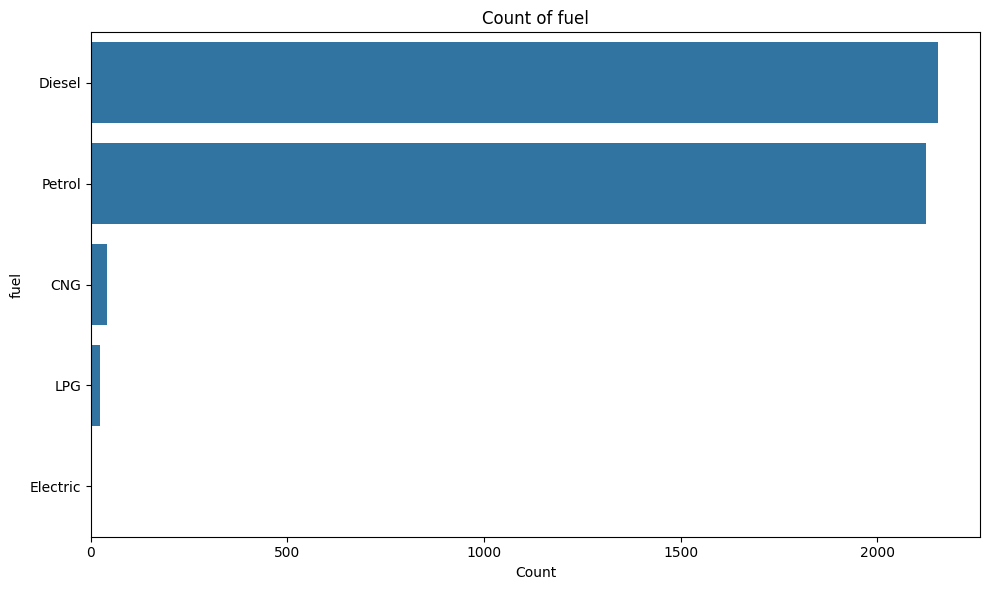

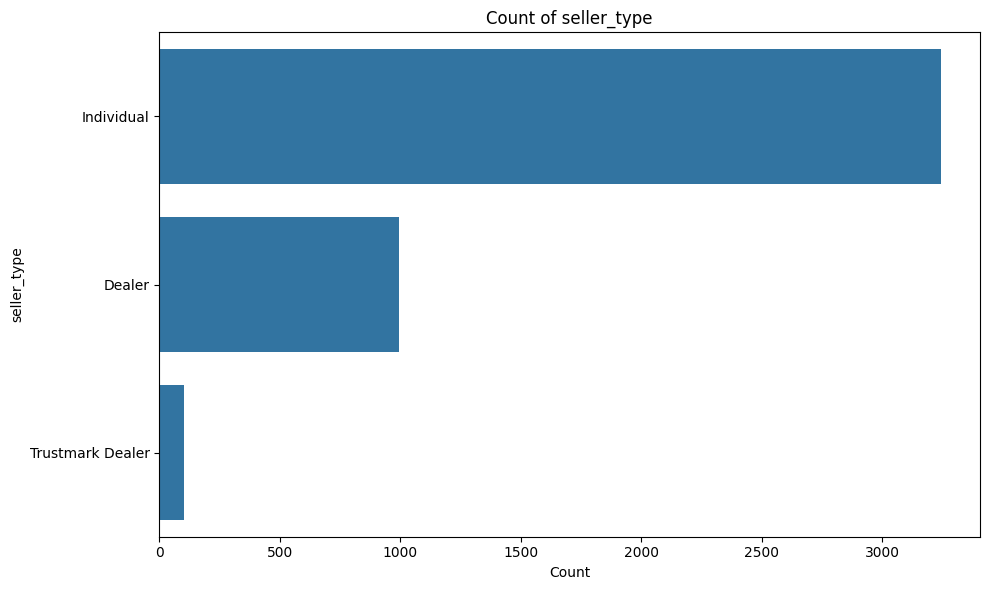

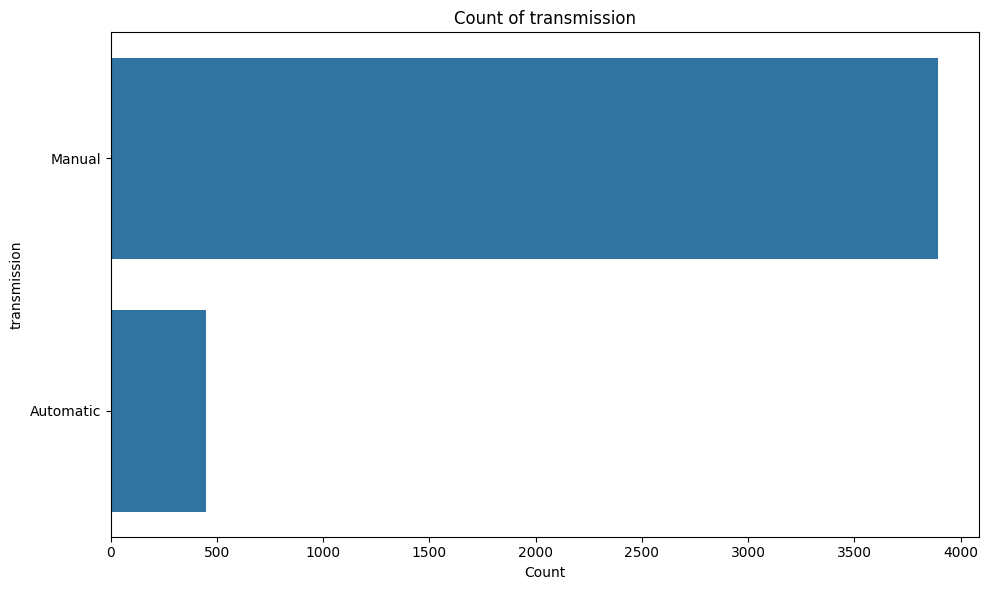

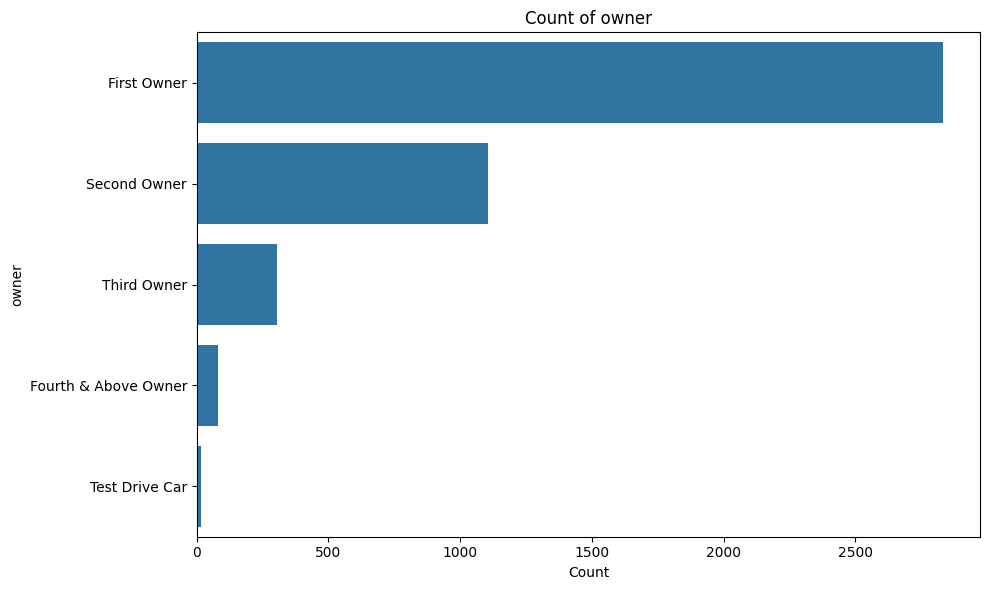

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df[col].dropna(), order = df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



    

#### In this cell I created visulization for the category/"object" columns. The data here is shown by a count of each unique object.
#### Name: this column is ver unclear, becuase there are too many unique names. Besides for a few on the top each car name appears pretty unoften.

#### Fuel: It seems like Deisel and Petrol fuel are te most common by far.

#### Seller Type. A Dealer seems about one third as common as an individual. And Trustmark Dealer is very rare.

#### Transmission: Most cars have a manual transmission compare to the few with automatic.

#### Owner: this column indicates how many previous owners the car had.

#### In the ollowing bunch of cells, each category is analyzed in context with the target variable. I am looking for the relationship between every variable and the price.

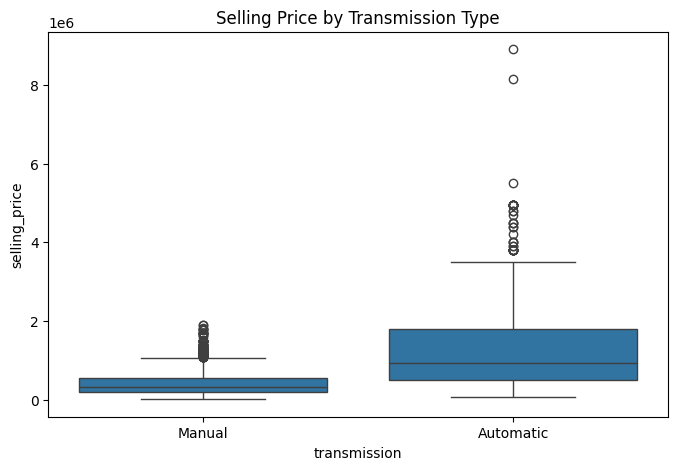

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='transmission', y='selling_price', data=df)
plt.title('Selling Price by Transmission Type')
plt.show()

#### This is a box and whisker plot that shows the correlation between the transmission type and the price of the vehicle. It seems that cars with an automatic transmission are signigicantly more expensive in comparison to the manual transmission.

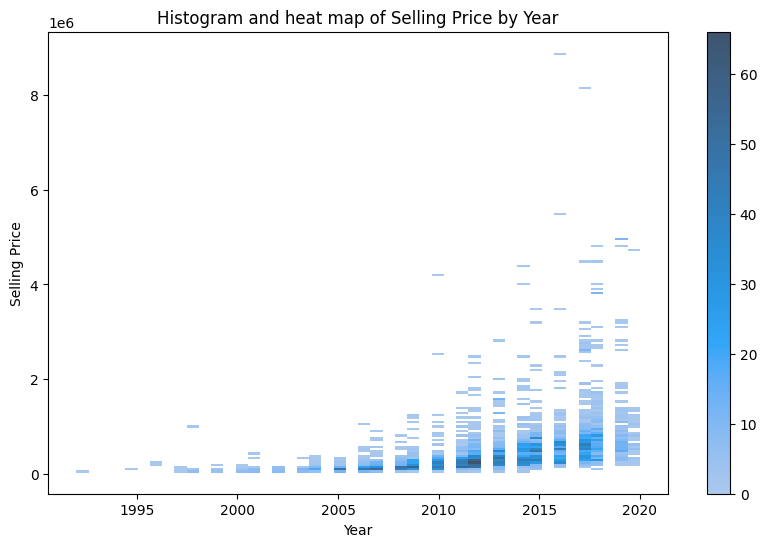

In [77]:
plt.figure(figsize=(10, 6))
sns.histplot(x='year', y='selling_price', data=df, cbar=True)
plt.title('Histogram and heat map of Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

#### The plot obove is a heat plot as well as a histogram that shows the correlation between the selling price and the year of the car. The color of each rectangle is based on the key to the right of it, and it shows how many cars at a specific year sold for a specific price. There is a positive correlation. The newer the model the more expensive the car.

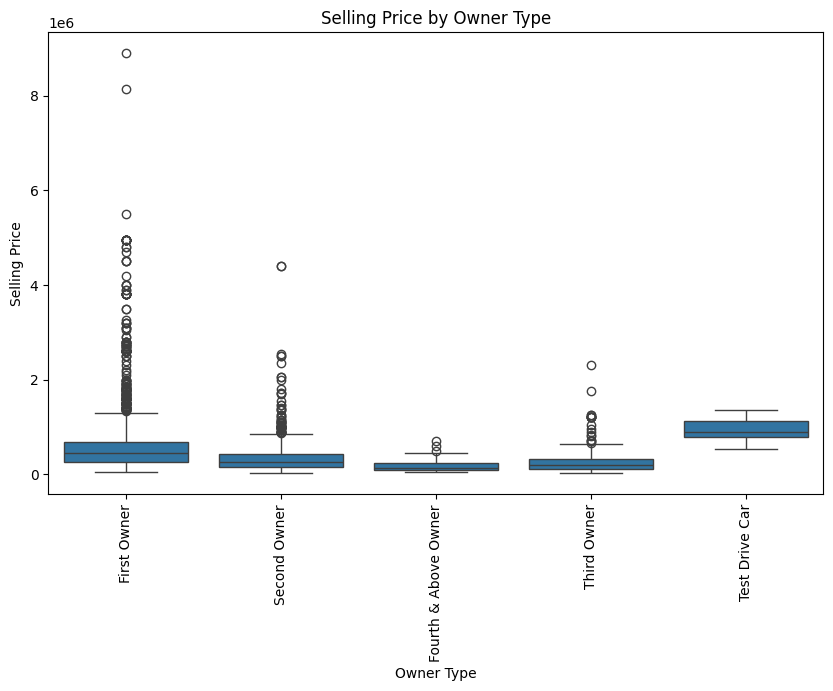

In [78]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='owner', y='selling_price', data=df)
plt.title('Selling Price by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Selling Price')
plt.xticks(rotation=90)
plt.show()

#### This plot copared the price by owner of the car. The results make a lot of sence. Cars only driven for a test drive havethe highest average price. One owner, is slightly cheaper, then two, three... It is a negative corrolation.

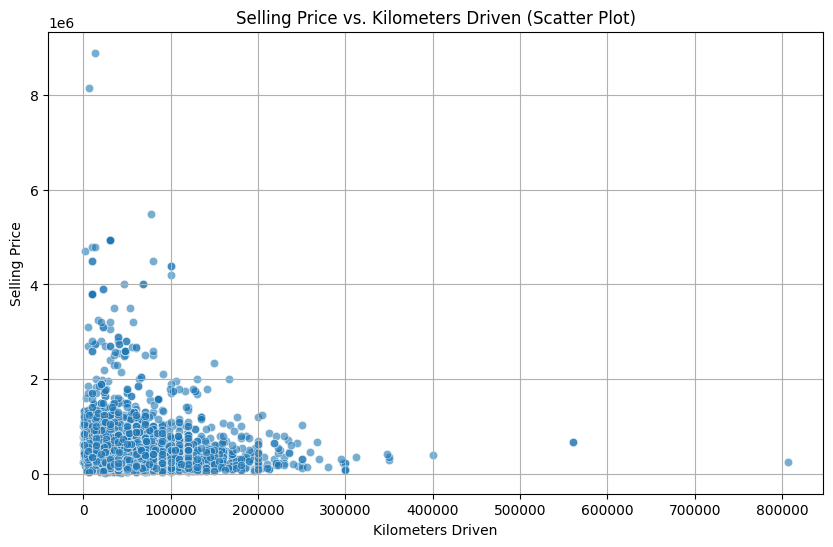

In [79]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='km_driven', y='selling_price', data=df, alpha=0.6)
plt.title('Selling Price vs. Kilometers Driven (Scatter Plot)')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()

#### Above is a scatter plot that shows the relationship between kilometers driven and the price. There is a negative correlation as the more kilometers driven the more cheaper the car.

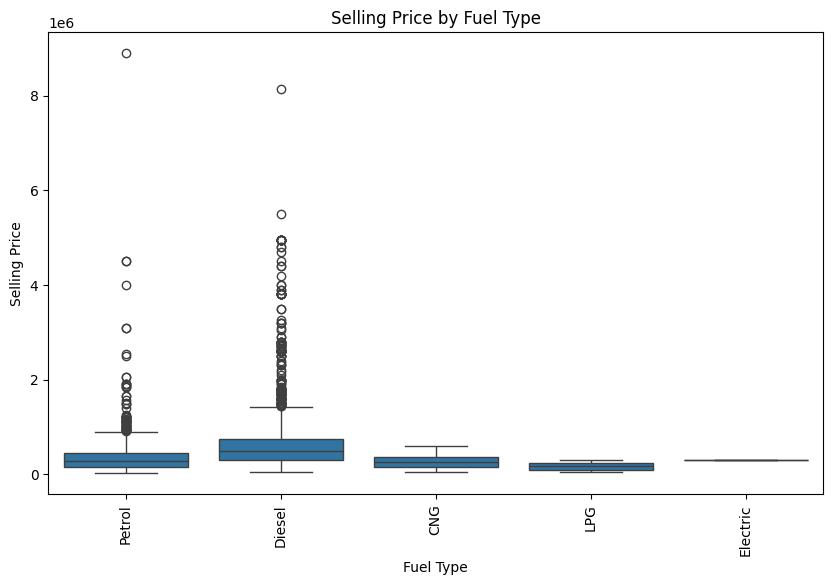

In [80]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='fuel', y='selling_price', data=df)
plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.xticks(rotation=90)
plt.show()

#### Above is a box-and-whisker histogram that shows the correlation between the fuel type and the price. Diesel usualy sells for the most, while Petrol and CNG look pretty equal at the least. (electric has the smallest range of prices, it seems there are very few cars with electric fuel.)

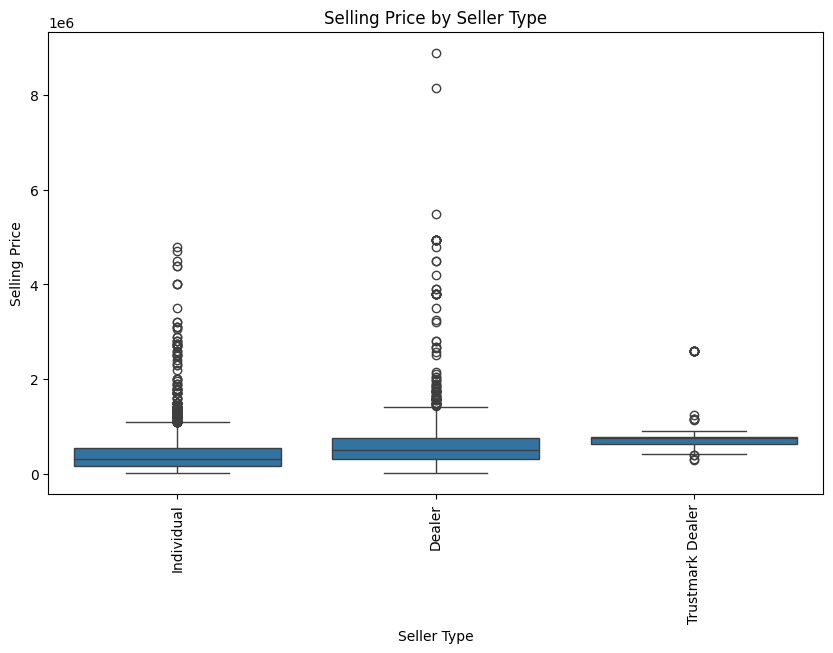

In [81]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='seller_type', y='selling_price', data=df)
plt.title('Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price')
plt.xticks(rotation=90)
plt.show()

#### Trade mark dealers seem to sell more expensive cars, after that is dealers, and after that, generaly the cheapest is individual sellers.

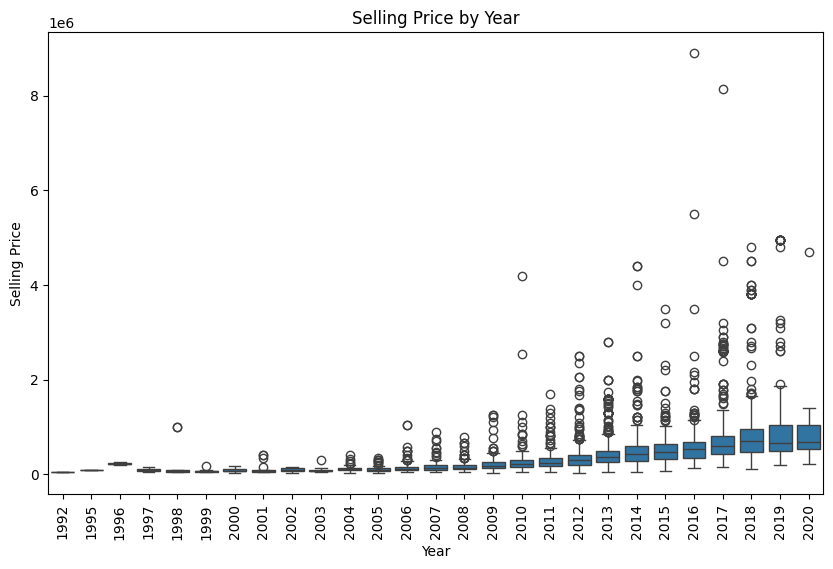

In [82]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='year', y='selling_price', data=df)
plt.title('Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.xticks(rotation=90)
plt.show()

The first time i made this plot the names of each year were running into each other and it was very unclear. I changed the code so that the labels were vertical. It is very clear that the newer the car the more expensive, generaly. It is interesting that 1996 is higher than the few before and after it, and 1998 has a far outlier.

#### Many of the models had groups of outliers...
#### Every model had a few real outliers, all the way on the top. It looks to me like there was a few cars that were major exception, and very expensive. they didn't follow the patterns... so every chart at random parts had crazy expensive outliers. I think the best way to handle them would be to get rid of it becuase they are so exceptional that they don't follow any pattern and they won't help with the study.

#### I will use this code to identify outliers in the numerical columns.


Outliers for year:


,name,year,selling_price
61,Mahindra Jeep CL 500 MDI,1996,250000
137,Maruti 800 Std,1998,40000
141,Hyundai Santro LP zipPlus,2003,75000
149,Hyundai Santro LE,2002,65000
187,Maruti Zen D,2003,75000
...,...,...,...
4020,Maruti Gypsy King HT BSIV,2001,409999
4132,Maruti Zen LXI,2003,70000
4153,Skoda Octavia Ambiente 1.9 TDI MT,2002,90000
4208,Toyota Qualis FS B3,2001,150000


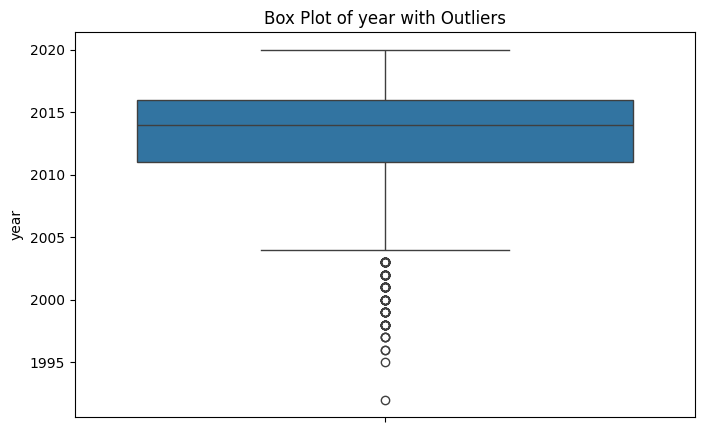


Outliers for selling_price:


,name,selling_price,selling_price
12,Toyota Corolla Altis 1.8 VL CVT,1650000,1650000
25,Toyota Corolla Altis 1.8 VL CVT,1650000,1650000
27,Hyundai Venue SX Opt Diesel,1195000,1195000
29,Jaguar XF 2.2 Litre Luxury,1964999,1964999
30,Mercedes-Benz New C-Class 220 CDI AT,1425000,1425000
...,...,...,...
4224,Toyota Fortuner 2.7 2WD AT,2500000,2500000
4228,Mahindra XUV500 W10 AWD,1225000,1225000
4304,Audi Q5 3.0 TDI Quattro Technology,3899000,3899000
4311,Toyota Camry Hybrid 2.5,1900000,1900000


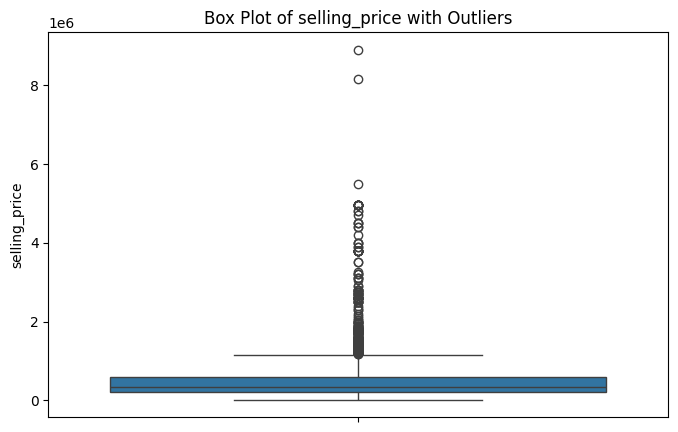


Outliers for km_driven:


,name,km_driven,selling_price
32,Audi Q5 2.0 TDI,175900,1190000
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,350000,280000
70,Toyota Corolla Altis Diesel D4DG,230000,350000
159,Chevrolet Enjoy 1.3 TCDi LS 8,175000,300000
197,Mahindra Xylo E4,230000,229999
...,...,...,...
4231,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,230000,800000
4255,Mahindra XUV500 W8 2WD,218000,650000
4275,Mahindra XUV500 W8 2WD,218000,650000
4286,Fiat Punto 1.3 Emotion,210000,130000


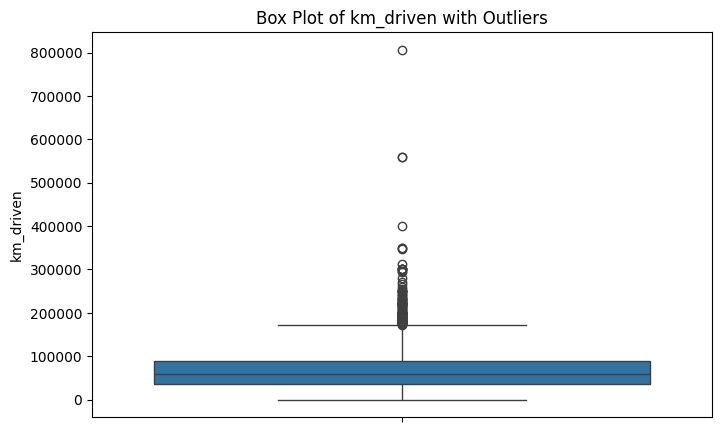

In [83]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\nOutliers for {col}:")
    display(outliers[['name', col, 'selling_price']])

    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} with Outliers')
    plt.show()

#### I will now scale the data so that the larger values don't influence the model disproportionately.

####

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled_numerical = scaler.fit_transform(df_cleaned[numerical_cols])
df_scaled_numerical = pd.DataFrame(df_scaled_numerical, columns=numerical_cols, index=df_cleaned.index)
non_numerical_cols_cleaned = df_cleaned.select_dtypes(exclude=['number']).columns
df_scaled = pd.concat([df_scaled_numerical, df_cleaned[non_numerical_cols_cleaned]], axis=1)

print("DataFrame with scaled numerical features:")
display(df_scaled.head())

DataFrame with scaled numerical features:


,year,selling_price,km_driven,name,fuel,seller_type,transmission,owner,brand
0,-1.678055,-1.385049,0.201925,Maruti 800 AC,Petrol,Individual,Manual,First Owner,Maruti
1,-1.678055,-1.080412,-0.348981,Maruti Wagon R LXI Minor,Petrol,Individual,Manual,First Owner,Maruti
2,-0.343058,0.808340,1.028283,Hyundai Verna 1.6 SX,Diesel,Individual,Manual,First Owner,Hyundai
3,0.991940,-0.613301,-0.459162,Datsun RediGO T Option,Petrol,Individual,Manual,First Owner,Datsun
4,0.190941,0.199065,2.157639,Honda Amaze VX i-DTEC,Diesel,Individual,Manual,Second Owner,Honda


In [84]:
df_cleaned = df.copy()
for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape (after outlier removal): {df_cleaned.shape}")
display(df_cleaned.head())

Original DataFrame shape: (4340, 8)
Cleaned DataFrame shape (after outlier removal): (3858, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


### The following cell is a matrix that shows, by percentage the strength of the correlation per numerical variable to the price. The values are positive and negative according to if the relationship is negative or positive. The number is a decimal in between 0 and 1. The higher the value the stronger the correlation.

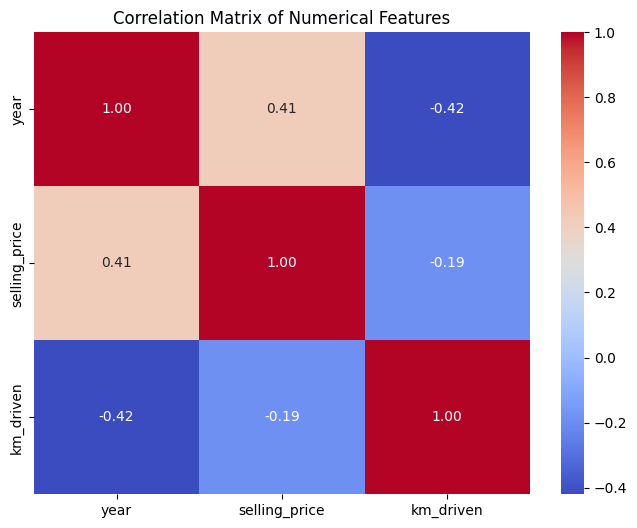

In [85]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The year is a big factor, it has a 41% positive correlation. This means that the newer the car the more expensive. And that the year of the car model makes a very big difference in the price of it. Kilometers driven has less of a stong correlation, with only -19%. the negative corrolation shows that the more km driven the cheaper the car.

#### So far only the numerical factors were in the matrix, in order to include those categories with objects we will encode the categories into numerical features so we can perform certain operations on them and make a matrix of the correlations.

In [86]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols_to_encode = ['fuel', 'seller_type', 'transmission', 'owner']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(df[categorical_cols_to_encode])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols_to_encode))
df_reset = df.reset_index(drop=True)
df_encoded = pd.concat([df_reset[numerical_cols], encoded_df], axis=1)

display(df_encoded.head())

,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007,60000,70000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,2007,135000,50000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,2012,600000,100000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,2017,250000,46000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,2014,450000,141000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


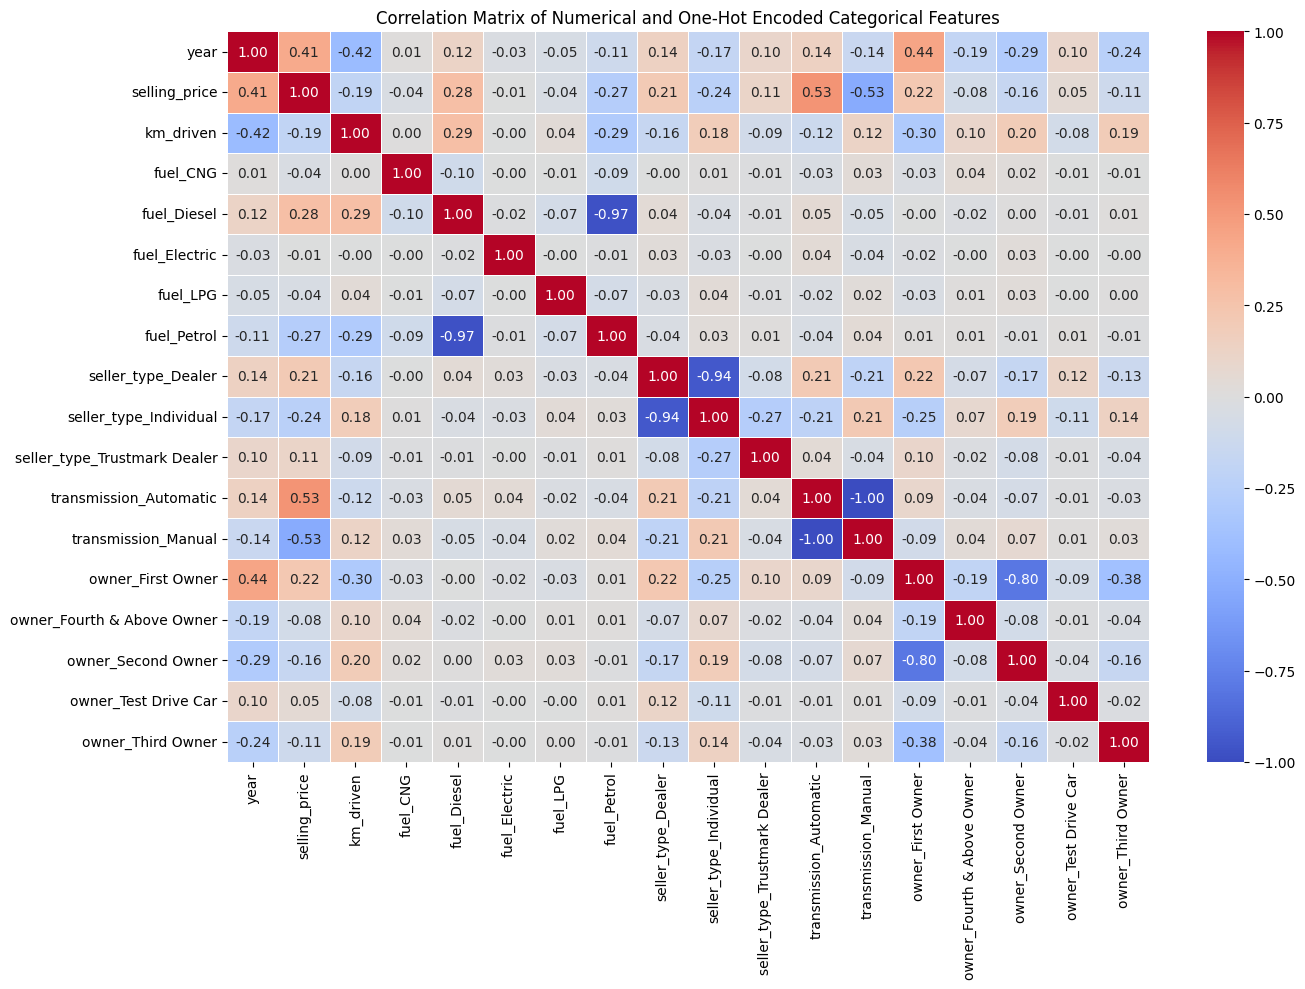

In [87]:
plt.figure(figsize=(14, 10)) # Adjust figure size for more features
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical and One-Hot Encoded Categorical Features')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### This matrix shows a strong posiitive correlation with a dark red, and a strong negative correlation with a dark blue.Since owr target factor is price we are focusing alont that row, to see the correlations. Deisel fuel and automatic transmission both have a very high positive correlation with the price. Manual transmission on the other hand, very sensibly has a negative correlation of the same strength.

The only correlation we didn't do yet was the name column. There are to many names to get any information from the data. If we extract the company name from each name, there may be a pattern that is more visible.The first word form each entree in the mane column was extracted and added to a new column called "brand".

In [88]:
df['brand'] = df['name'].apply(lambda x: x.split(' ')[0])
display(df.head())

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


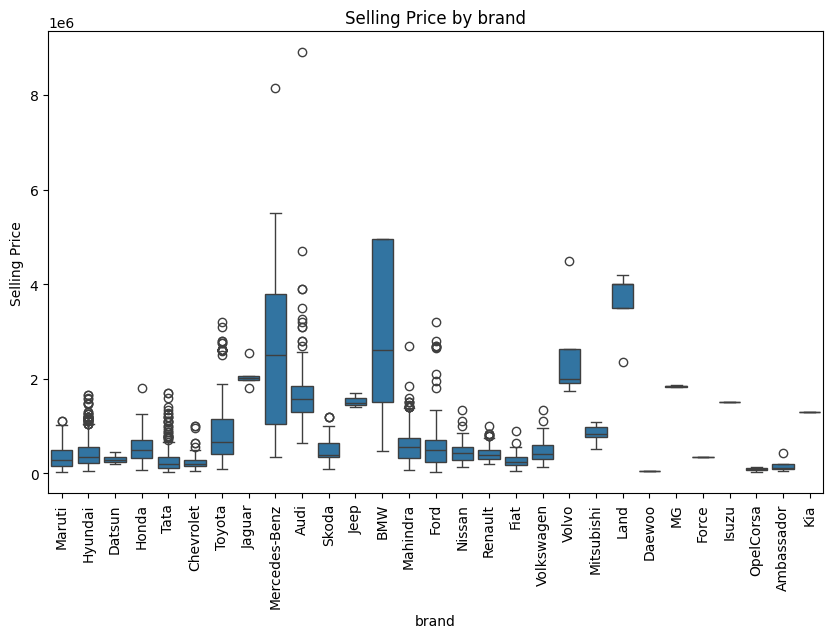

In [89]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='brand', y='selling_price', data=df)
plt.title('Selling Price by brand')
plt.xlabel('brand')
plt.ylabel('Selling Price')
plt.xticks(rotation=90)
plt.show()

#### There is no order with the brands, some of the expensive brands include: Marcedes, and BMW. The cheaper ones include: Datsum, Cheverolet...

##### Encoding the name column...

In [90]:
encoder_brand = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_brand_features = encoder_brand.fit_transform(df['brand'].values.reshape(-1, 1))
encoded_brand_df = pd.DataFrame(encoded_brand_features, columns=encoder_brand.get_feature_names_out(['brand']))
display(encoded_brand_df.head())


,brand_Ambassador,brand_Audi,brand_BMW,brand_Chevrolet,brand_Daewoo,brand_Datsun,brand_Fiat,brand_Force,brand_Ford,brand_Honda,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [91]:
df_encoded.reset_index(drop=True, inplace=True)
df_final_encoded = pd.concat([df_encoded, encoded_brand_df], axis=1)
display(df_final_encoded.head())

,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2007,60000,70000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2007,135000,50000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2012,600000,100000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017,250000,46000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2014,450000,141000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### I redid the matrix with the different car companies included.

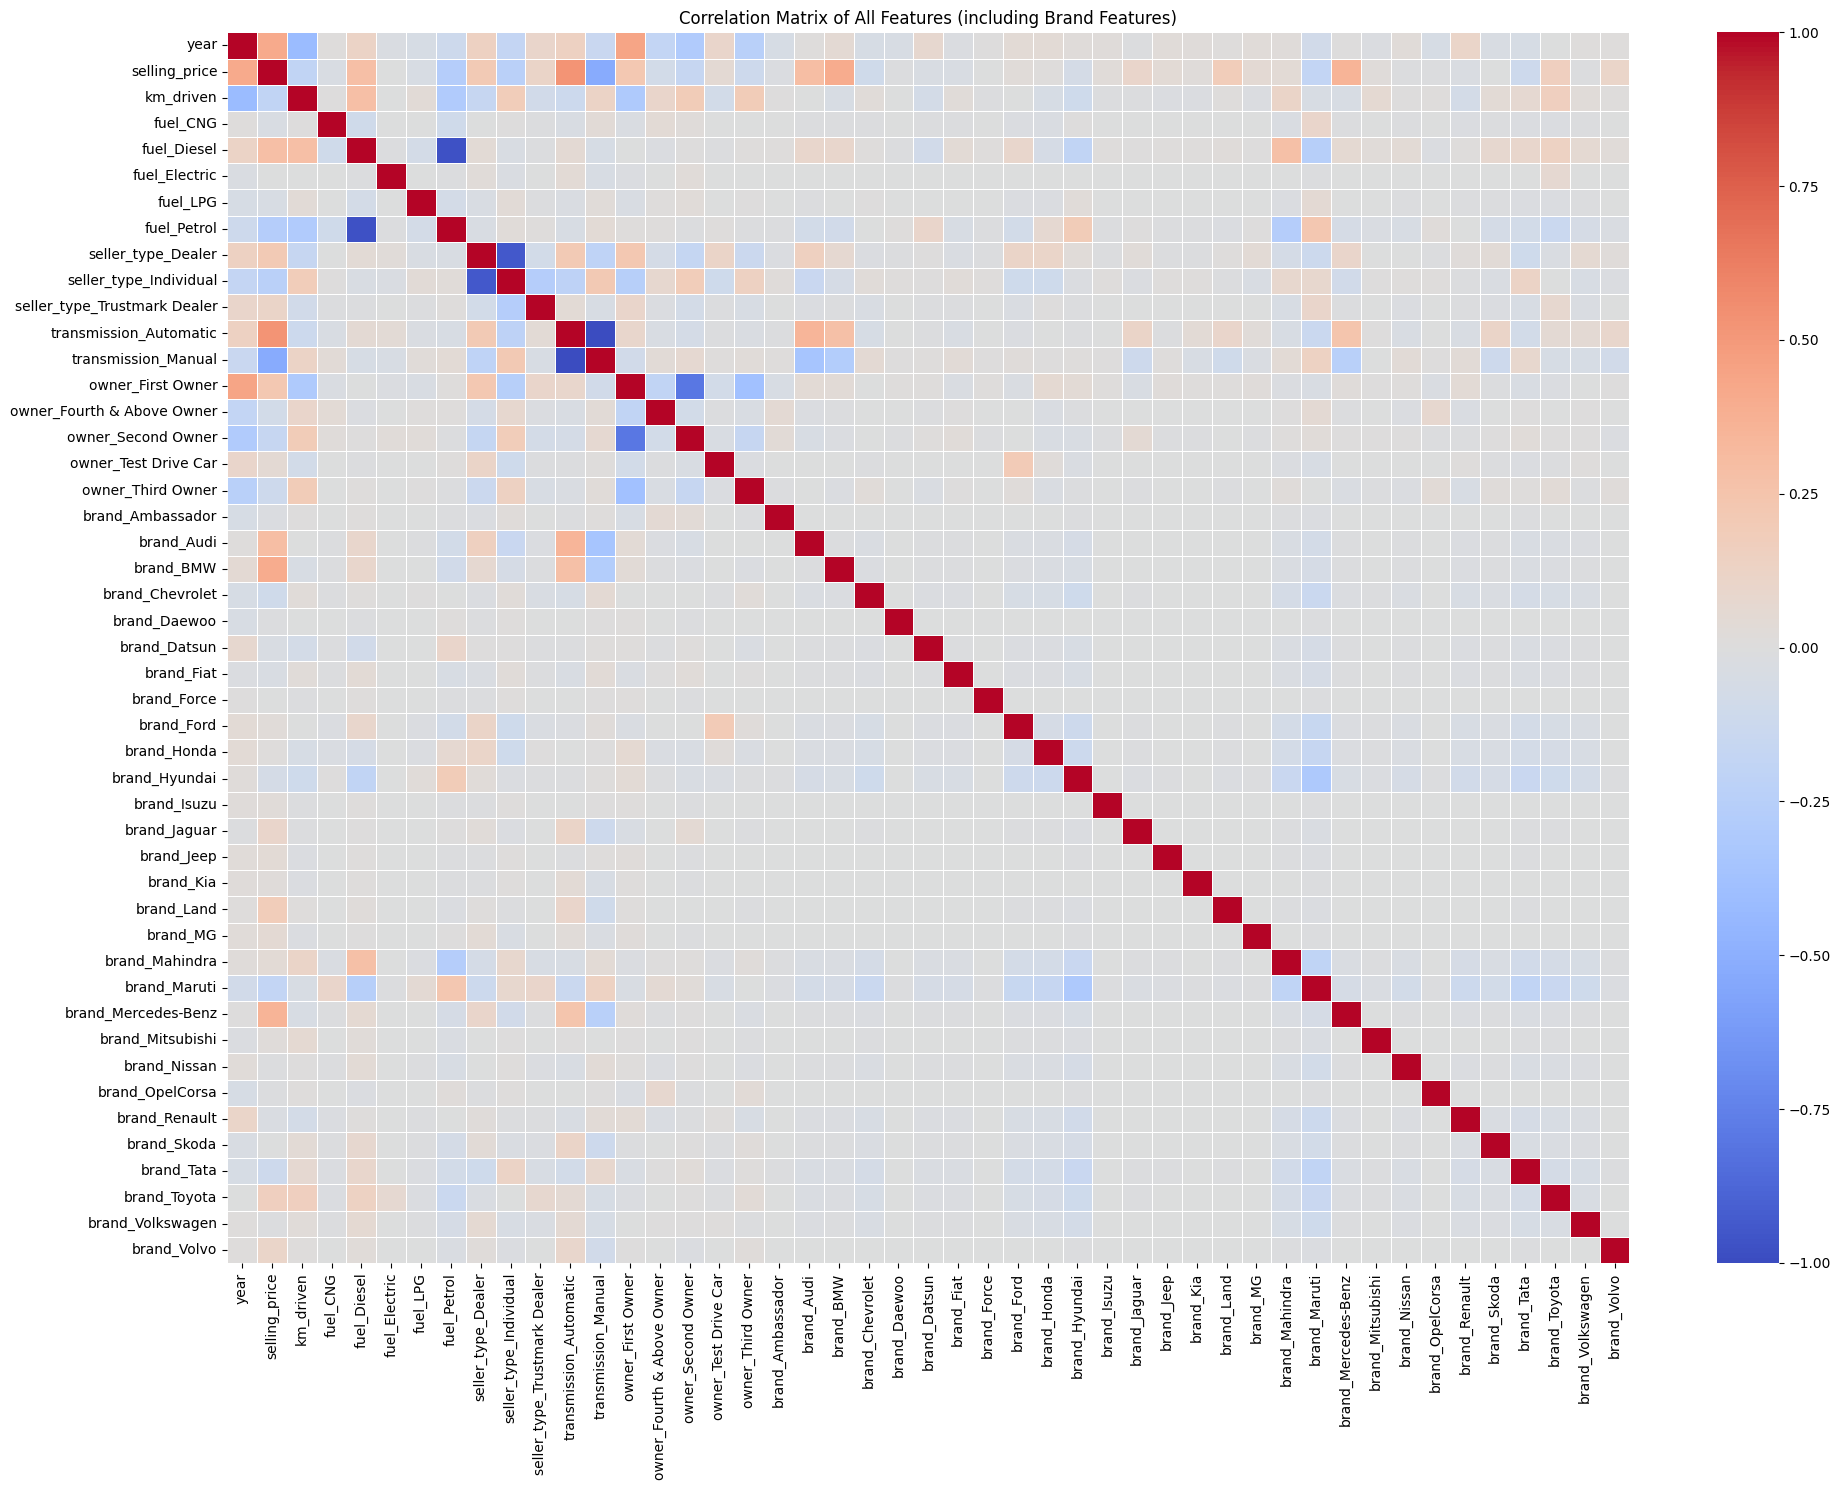

In [92]:
plt.figure(figsize=(20, 15)) # Adjust figure size for many features
sns.heatmap(df_final_encoded.corr(), annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of All Features (including Brand Features)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Most of the boxes ended up grey - no strong correlation either way. I think this is becuase there are too many companies to have a srong enough appearance for a specific company.

#### Looking ahead I would start by splitting my data into test and train section so whatever model I use I can train the data as well as test its accuracy.

#### I would start with a linear regression model. A linear regression model is essntially similar to a scatter plot, with a line of best fit across the data. This line is the predicted value for every variable at any point on the line.
#### this line is great to use to predict the price of car based on its variables.

#### I will create a multi Linear Regression model so that I can find the predicted price taking into account many variables at once.

### Metrics:
#### I will use the test part of my data to test and evaluate if my model is accurate. The metrics are as follows:

*	MAE – I want to see what the average error is, and how many dollars off is the model’s guess.
*	RMSE – This helps to see if there are any very big mistakes.
* R-Squared – This tells what percentage of the price is explainable with data.
